# Denoising Autoencoder (Gaussian Blur) on Oxford-IIIT Pet — Optuna

Plain convolutional autoencoder with **no skip connections**, ported from Keras to PyTorch. The encoder uses two stages, and a separately configurable bottleneck produces the 32×32 latent representation for 128×128 inputs.

## Plan
| # | Step | What happens |
|---|------|--------------|
| 1 | Setup | Imports, config (image size, noise level, epochs), device |
| 2 | Data | Load the repository's local Oxford-IIIT Pet images and official train / val / test splits |
| 3 | Corruption | Runtime Gaussian blur using the assignment's kernel and sigma ranges; visual sanity check |
| 4 | Model | No-skip convolutional autoencoder with a configurable 32×32 bottleneck |
| 5 | Train | Adam + weighted L1/SSIM loss, fresh noise every batch, track train/val loss |
| 6 | Curves | Plot loss, pick best epoch |
| 7 | Test | PSNR and SSIM on the held-out test split: noisy vs. denoised |
| 8 | Visuals | Noisy / denoised / clean grid |
| 9 | Severity evaluation | Evaluate the assignment's low, medium, and high Gaussian blur settings |
| 10 | Save | Save and reload weights and selected Optuna parameters |
| 11 | Save | Save and reload weights |

**Corruption rule:** every training image receives a runtime Gaussian blur with kernel size 3, 5, or 7 and standard deviation sampled uniformly from 0.5 to 2.5.


## 1. Setup

In [1]:
!pip install -q torchmetrics scipy optuna wandb

import gc, time, random, json
from pathlib import Path
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import functional as TF
from PIL import Image
import matplotlib.pyplot as plt
import optuna
import wandb
from optuna.trial import TrialState
from torchmetrics.image import StructuralSimilarityIndexMeasure
from torchmetrics.functional import structural_similarity_index_measure

# ---------------- config ----------------
IMG_SIZE    = 128      # the article uses 240; 128 is faster and lighter on memory
BATCH_SIZE  = 32
EPOCHS      = 30
TRIALS      = 20
TRIAL_EPOCHS = 8

# Explicit Optuna search space
OPTUNA_SEARCH_SPACE = {
    "batch_size": [16, 32, 64],
    "base_channels": [32, 48, 64],
    "bottleneck_channels": [32, 64, 96, 128],
    "learning_rate": {"low": 1e-4, "high": 3e-3, "log": True},
    "alpha": {"low": 0.60, "high": 0.95},
}
LR          = 1e-3
TRAIN_BLUR_KERNELS = [3, 5, 7]
TRAIN_SIGMA_RANGE = (0.5, 2.5)
SEED        = 42
NUM_WORKERS = 2
WANDB_PROJECT = "genai-assignment-1"
WANDB_RUN_NAME = "dae-gaussian-blur-optuna"
# ----------------------------------------

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

wandb_run = wandb.init(
    project=WANDB_PROJECT,
    name=WANDB_RUN_NAME,
    config={
        "corruption": "gaussian_blur", "image_size": IMG_SIZE,
        "epochs": EPOCHS, "optuna_trials": TRIALS, "trial_epochs": TRIAL_EPOCHS,
        "seed": SEED, "train_blur_kernels": TRAIN_BLUR_KERNELS,
        "train_sigma_range": TRAIN_SIGMA_RANGE, "search_space": OPTUNA_SEARCH_SPACE,
    },
)


/home/zaifi/genai-assignment-1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Device: cuda


wandb: Currently logged in as: i230510 (i230510-fast-nuces-islamabad) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 2. Data — local Oxford-IIIT Pet dataset
Images and official split manifests are read from the repository's `research/datasets` folder. This avoids downloading another copy from torchvision.


In [2]:
# Find the repository root from either the repo root or research/notebooks as the Jupyter working directory.
_here = Path.cwd().resolve()
_repo_candidates = [_here, *_here.parents]
REPO_ROOT = next(
    (p for p in _repo_candidates if (p / "research/datasets/oxford-iiit-pet/images").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not find research/datasets/oxford-iiit-pet/images. "
        "Run this notebook from within the repository."
    )

PET_IMAGES_DIR = REPO_ROOT / "research/datasets/oxford-iiit-pet/images"
SPLIT_MANIFEST = REPO_ROOT / "research/split_manifest_official.json"
if not SPLIT_MANIFEST.is_file():
    raise FileNotFoundError(f"Official split manifest not found: {SPLIT_MANIFEST}")
with SPLIT_MANIFEST.open() as f:
    split_manifest = json.load(f)

class LocalPetImages(Dataset):
    """Clean Oxford-IIIT Pet images loaded from the repository's dataset folder."""
    def __init__(self, filenames, transform):
        self.paths = [PET_IMAGES_DIR / name for name in filenames]
        missing = [path for path in self.paths if not path.is_file()]
        if missing:
            raise FileNotFoundError(f"Missing dataset image, for example: {missing[0]}")
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        with Image.open(self.paths[idx]) as image:
            clean = self.transform(image.convert("RGB"))
        # The training code ignores labels; return a placeholder for its existing batch format.
        return clean, 0

tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),            # float in [0, 1], shape (3, H, W)
])

train_ds = LocalPetImages(split_manifest["train"], tfm)
val_ds   = LocalPetImages(split_manifest["val"], tfm)
test_ds  = LocalPetImages(split_manifest["test"], tfm)
print(f"Dataset: {PET_IMAGES_DIR}")
print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

# labels are ignored: the target is the clean image itself
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


Dataset: /home/zaifi/genai-assignment-1/research/datasets/oxford-iiit-pet/images
train=2944  val=736  test=3669


## 3. Gaussian blur

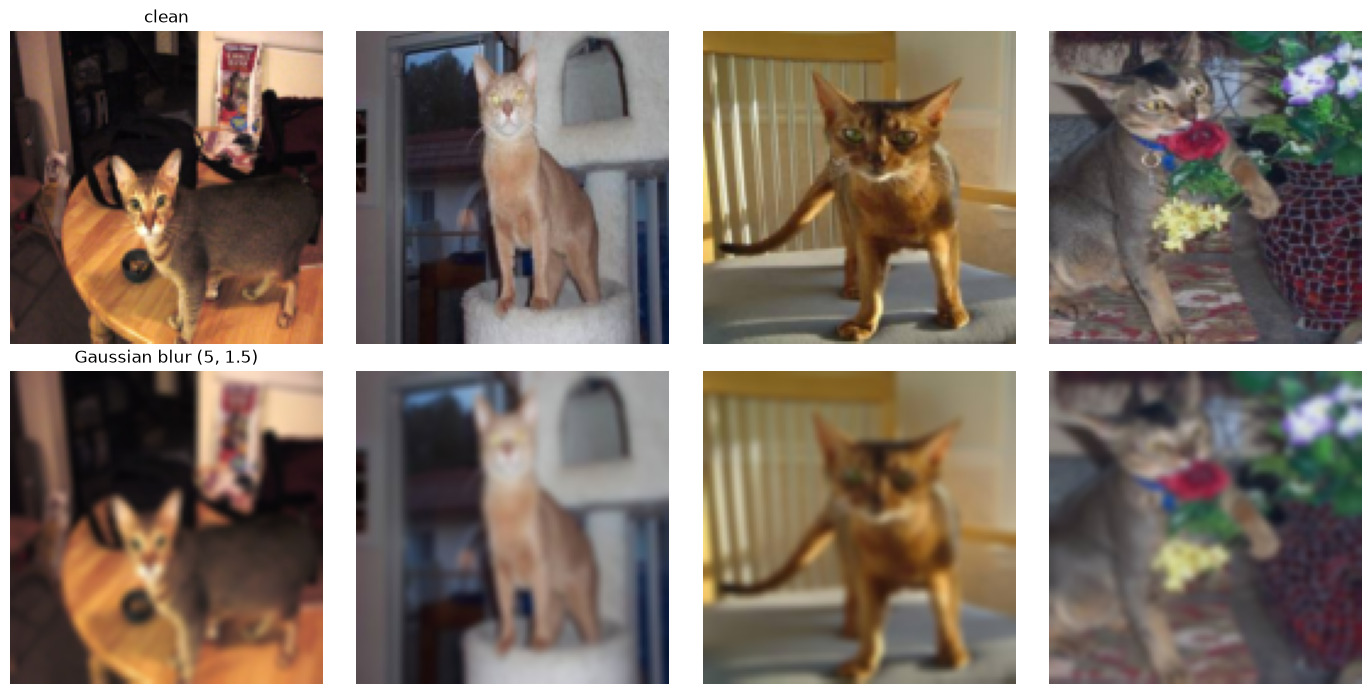

In [3]:
def add_gaussian_blur(x, kernel_sizes=TRAIN_BLUR_KERNELS, sigma_range=TRAIN_SIGMA_RANGE, generator=None):
    """Apply independently sampled assignment-compliant blur settings to each image."""
    blurred = []
    for image in x:
        kernel_index = torch.randint(len(kernel_sizes), (), device=x.device, generator=generator).item()
        kernel_size = kernel_sizes[kernel_index]
        sigma = torch.empty((), device=x.device).uniform_(*sigma_range, generator=generator).item()
        blurred.append(TF.gaussian_blur(image, [kernel_size, kernel_size], [sigma, sigma]))
    return torch.stack(blurred)

# visual sanity check
x, _ = next(iter(test_loader))
x = x[:4].to(device)
fig, ax = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    ax[0, i].imshow(x[i].permute(1, 2, 0).cpu());                              ax[0, i].axis("off")
    ax[1, i].imshow(add_gaussian_blur(x, kernel_sizes=[5], sigma_range=(1.5, 1.5))[i].permute(1, 2, 0).cpu()); ax[1, i].axis("off")
ax[0, 0].set_title("clean"); ax[1, 0].set_title("Gaussian blur (5, 1.5)")
plt.tight_layout(); plt.show()

## 4. Model
The encoder has two two-convolution stages. In each stage, the first convolution changes the channel width while preserving spatial size, and the second keeps the width while halving spatial size. A separate bottleneck convolution sets the latent channel count at 32×32 resolution. The two-stage decoder reverses the encoder widths while upsampling to the original resolution, with no skip connections.


In [4]:
class DenoisingAE(nn.Module):
    def __init__(self, base_channels=64, bottleneck_channels=128):
        super().__init__()
        c1 = base_channels
        c2 = base_channels * 2

        # Each stage first changes channels at fixed resolution, then downsamples.
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, c1, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c1, c1, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(c1, c2, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c2, c2, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )

        # The bottleneck width is searched independently from encoder width.
        self.bottleneck = nn.Sequential(
            nn.Conv2d(c2, bottleneck_channels, 3, padding=1),
            nn.ReLU(inplace=True),
        )

        # Mirror the encoder without concatenating any encoder features.
        self.dec2 = nn.Sequential(
            nn.Conv2d(bottleneck_channels, c2, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c2, c1, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.dec1 = nn.Sequential(
            nn.Conv2d(c1, c1, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c1, 3, 3, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        return self.bottleneck(self.enc2(self.enc1(x)))

    def forward(self, x):
        z = self.encode(x)  # (B, bottleneck_channels, H/4, W/4)
        x = F.interpolate(z, scale_factor=2, mode="bilinear")
        x = self.dec2(x)
        x = F.interpolate(x, scale_factor=2, mode="bilinear")
        return self.dec1(x)

model = DenoisingAE(base_channels=64).to(device)
print(model)
print("Params:", sum(p.numel() for p in model.parameters()))
with torch.no_grad():
    dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    print("Bottleneck:", tuple(model.encode(dummy).shape), "| Output:", tuple(model(dummy).shape))


DenoisingAE(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (bottleneck): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (dec2): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (dec1): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 3, k

## 5. Optuna search and final training

Optuna minimizes the validation value of the same weighted L1 + (1 − SSIM) loss used for training. The search space is declared explicitly in `OPTUNA_SEARCH_SPACE`: batch size `{16, 32, 64}`, base channels `{32, 48, 64}`, bottleneck channels `{32, 64, 96, 128}`, learning rate `1e-4` to `3e-3` on a log scale, and loss weight `alpha` from `0.60` to `0.95`. Trials use a short schedule; the winning configuration is then trained for the original 30 epochs, with the best validation checkpoint retained. Validation noise is fixed across epochs and trials for a fair comparison.

In [ ]:
# Assignment Task 1 loss: alpha * L1 + (1 - alpha) * (1 - SSIM).
def ae_loss(pred, target, alpha):
    l1 = F.l1_loss(pred, target)
    ssim = structural_similarity_index_measure(pred, target, data_range=1.0)
    return alpha * l1 + (1.0 - alpha) * (1.0 - ssim)

def run_epoch(model, loader, optimizer=None, alpha=0.8, seed=None):
    training = optimizer is not None
    model.train(training)
    gen = None
    if seed is not None:
        gen = torch.Generator(device=device)
        gen.manual_seed(seed)
    total, n = 0.0, 0
    with torch.set_grad_enabled(training):
        for clean, _ in loader:
            clean = clean.to(device, non_blocking=True)
            noisy = add_gaussian_blur(clean, generator=gen)
            out = model(noisy)
            loss = ae_loss(out, clean, alpha)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total += loss.item() * clean.size(0)
            n += clean.size(0)
    return total / n

def make_loaders(batch_size=BATCH_SIZE):
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
    )
    return train_loader, val_loader

def objective(trial):
    batch_size = trial.suggest_categorical("batch_size", OPTUNA_SEARCH_SPACE["batch_size"])
    base_channels = trial.suggest_categorical("base_channels", OPTUNA_SEARCH_SPACE["base_channels"])
    bottleneck_channels = trial.suggest_categorical("bottleneck_channels", OPTUNA_SEARCH_SPACE["bottleneck_channels"])
    lr_space = OPTUNA_SEARCH_SPACE["learning_rate"]
    lr = trial.suggest_float("lr", lr_space["low"], lr_space["high"], log=lr_space["log"])
    alpha_space = OPTUNA_SEARCH_SPACE["alpha"]
    alpha = trial.suggest_float("alpha", alpha_space["low"], alpha_space["high"])
    random.seed(SEED + trial.number)
    np.random.seed(SEED + trial.number)
    torch.manual_seed(SEED + trial.number)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED + trial.number)

    train_loader, val_loader = make_loaders(batch_size)
    trial_model = DenoisingAE(base_channels=base_channels, bottleneck_channels=bottleneck_channels).to(device)
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr)
    best_trial_val = float("inf")
    try:
        for epoch in range(1, TRIAL_EPOCHS + 1):
            train_loss = run_epoch(trial_model, train_loader, optimizer, alpha=alpha)
            val_loss = run_epoch(trial_model, val_loader, alpha=alpha, seed=SEED)
            best_trial_val = min(best_trial_val, val_loss)
            trial.report(val_loss, step=epoch)
            wandb.log({
                "optuna/trial": trial.number, "optuna/epoch": epoch,
                "optuna/train_loss": train_loss, "optuna/validation_loss": val_loss,
                "optuna/best_validation_loss": best_trial_val,
                "optuna/batch_size": batch_size, "optuna/base_channels": base_channels,
                "optuna/bottleneck_channels": bottleneck_channels,
                "optuna/learning_rate": lr, "optuna/alpha": alpha,
            })
            print(
                f"Trial {trial.number:03d} | epoch {epoch:02d}/{TRIAL_EPOCHS} | "
                f"batch={batch_size} base={base_channels} bottleneck={bottleneck_channels} "
                f"alpha={alpha:.3f} lr={lr:.2g} | "
                f"train={train_loss:.4f} val={val_loss:.4f}"
            )
            if trial.should_prune():
                raise optuna.TrialPruned()
        return best_trial_val
    finally:
        del trial_model, optimizer, train_loader, val_loader
        if device.type == "cuda":
            torch.cuda.empty_cache()
        gc.collect()

STUDY_NAME = "dae_gaussian_blur_optuna"
STORAGE = f"sqlite:///{REPO_ROOT / 'research/notebooks/dae_gaussian_blur_optuna.db'}"
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2)
study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=STORAGE,
    load_if_exists=True,
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=pruner,
)
study.optimize(objective, n_trials=TRIALS)

completed_trials = [t for t in study.trials if t.state == TrialState.COMPLETE]
pruned_trials = [t for t in study.trials if t.state == TrialState.PRUNED]
print(f"Complete trials: {len(completed_trials)} | pruned trials: {len(pruned_trials)}")
print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)
wandb.config.update({f"best_{key}": value for key, value in study.best_params.items()})
wandb.summary["optuna/best_validation_loss"] = study.best_value

# Visualize completed trials by channel width, with color showing alpha.
plt.figure(figsize=(8, 4))
plt.scatter(
    [t.params["base_channels"] for t in completed_trials],
    [t.value for t in completed_trials],
    c=[t.params["alpha"] for t in completed_trials], cmap="viridis", s=65,
)
plt.xticks([32, 48, 64])
plt.xlabel("Base channel width")
plt.ylabel("Best validation weighted L1 + (1 - SSIM)")
plt.title("Optuna trials: model width and loss weight")
plt.colorbar(label="Alpha")
plt.grid(alpha=0.25)
plt.show()

# Retrain the best configuration with the source notebook's full training schedule.
best_params = study.best_params
ALPHA = best_params["alpha"]
LR = best_params["lr"]
BATCH_SIZE = best_params["batch_size"]
BASE_CHANNELS = best_params["base_channels"]
BOTTLENECK_CHANNELS = best_params["bottleneck_channels"]
set_seed(SEED)
train_loader, val_loader = make_loaders(BATCH_SIZE)
model = DenoisingAE(base_channels=BASE_CHANNELS, bottleneck_channels=BOTTLENECK_CHANNELS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
history = {"loss": [], "val_loss": []}
best_val = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr = run_epoch(model, train_loader, optimizer, alpha=ALPHA)
    va = run_epoch(model, val_loader, alpha=ALPHA, seed=SEED)
    history["loss"].append(tr)
    history["val_loss"].append(va)
    wandb.log({"epoch": epoch, "train/loss": tr, "validation/loss": va, "learning_rate": LR})
    if va < best_val:
        best_val = va
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    print(
        f"Epoch {epoch:02d}/{EPOCHS} train={tr:.4f} val={va:.4f} "
        f"({time.time() - t0:.0f}s)"
    )

model.load_state_dict(best_state)
model.to(device).eval()
print(f"Best val loss: {best_val:.4f} | batch={BATCH_SIZE} | base={BASE_CHANNELS} | bottleneck={BOTTLENECK_CHANNELS} | alpha={ALPHA:.3f} | lr={LR:.2g}")


[I 2026-10-04 09:17:01,810] A new study created in RDB with name: dae_gaussian_blur_optuna
/home/zaifi/genai-assignment-1/.venv/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Trial 000 | epoch 01/8 | batch=32 base=32 bottleneck=64 alpha=0.939 lr=0.00011 | train=0.1925 val=0.1149
Trial 000 | epoch 02/8 | batch=32 base=32 bottleneck=64 alpha=0.939 lr=0.00011 | train=0.1072 val=0.1019


## 6. Loss curves

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history["loss"], label="Training loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.axvline(int(np.argmin(history["val_loss"])), ls="--", c="gray", label="best epoch")
plt.title(f"Training and Validation Loss (L1 + SSIM, alpha={ALPHA:g})"); plt.xlabel("Epoch"); plt.ylabel("Weighted L1 + (1 - SSIM) loss")
plt.legend(); plt.show()


## 7. Test-set evaluation (PSNR / SSIM)
A fixed seed means the *same* corrupted test images are used every time you run this.

In [ ]:
def psnr_batch(a, b):
    mse = ((a - b) ** 2).flatten(1).mean(1).clamp_min(1e-10)
    return 10 * torch.log10(1.0 / mse)          # per-image PSNR, data range [0, 1]

@torch.no_grad()
def evaluate(model, loader, kernel_size=5, sigma=1.5, seed=123):
    model.eval()
    gen = torch.Generator(device=device); gen.manual_seed(seed)
    ssim_n = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    ssim_d = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    p_n, p_d = [], []
    for clean, _ in loader:
        clean = clean.to(device)
        noisy = add_gaussian_blur(clean, kernel_sizes=[kernel_size], sigma_range=(sigma, sigma), generator=gen)
        den   = model(noisy)
        p_n.append(psnr_batch(noisy, clean)); p_d.append(psnr_batch(den, clean))
        ssim_n.update(noisy, clean);          ssim_d.update(den, clean)
    return dict(psnr_noisy=torch.cat(p_n).mean().item(), psnr_denoised=torch.cat(p_d).mean().item(),
                ssim_noisy=ssim_n.compute().item(),      ssim_denoised=ssim_d.compute().item())

res = evaluate(model, test_loader, kernel_size=5, sigma=1.5)
print("Gaussian blur: kernel=5, sigma=1.5")
print(f"PSNR  noisy: {res['psnr_noisy']:.2f} dB  ->  denoised: {res['psnr_denoised']:.2f} dB")
print(f"SSIM  noisy: {res['ssim_noisy']:.4f}     ->  denoised: {res['ssim_denoised']:.4f}")
wandb.log({
    "test/kernel_size": 5, "test/sigma": 1.5,
    **{f"test/{key}": value for key, value in res.items()},
})

## 8. Visual results

In [ ]:
@torch.no_grad()
def show_results(model, dataset, kernel_size=5, sigma=1.5, n=6, seed=7):
    model.eval()
    idx = random.Random(seed).sample(range(len(dataset)), n)
    clean = torch.stack([dataset[i][0] for i in idx]).to(device)
    gen = torch.Generator(device=device); gen.manual_seed(seed)
    noisy = add_gaussian_blur(clean, kernel_sizes=[kernel_size], sigma_range=(sigma, sigma), generator=gen)
    den = model(noisy)
    p_n, p_d = psnr_batch(noisy, clean), psnr_batch(den, clean)

    rows = [("Noisy", noisy, p_n), ("Denoised", den, p_d), ("Clean", clean, None)]
    fig, ax = plt.subplots(3, n, figsize=(2.6 * n, 8))
    for r, (name, imgs, p) in enumerate(rows):
        for c in range(n):
            ax[r, c].imshow(imgs[c].permute(1, 2, 0).clamp(0, 1).cpu()); ax[r, c].axis("off")
            if p is not None: ax[r, c].set_title(f"{name}\n{p[c]:.1f} dB", fontsize=9)
            else:             ax[r, c].set_title(name, fontsize=9)
    plt.tight_layout(); plt.show()

show_results(model, test_ds)

## 9. Required Gaussian blur severity sweep
The assignment specifies the three deterministic test settings shown below.

In [ ]:
levels = [(3, 0.7), (5, 1.5), (7, 2.5)]
rows = []
for kernel_size, sigma in levels:
    r = evaluate(model, test_loader, kernel_size, sigma)
    rows.append((f"({kernel_size}, {sigma})", r["psnr_noisy"], r["psnr_denoised"], r["ssim_noisy"], r["ssim_denoised"]))
    print(f"kernel={kernel_size}, sigma={sigma:.1f} | PSNR {r['psnr_noisy']:5.2f} -> {r['psnr_denoised']:5.2f} dB | SSIM {r['ssim_noisy']:.3f} -> {r['ssim_denoised']:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
labels = [r[0] for r in rows]
ax[0].plot(labels, [r[1] for r in rows], "o-", label="blurred"); ax[0].plot(labels, [r[2] for r in rows], "o-", label="denoised")
ax[0].set(title="PSNR by Gaussian blur severity", xlabel="(kernel, sigma)", ylabel="dB"); ax[0].legend()
ax[1].plot(labels, [r[3] for r in rows], "o-", label="blurred"); ax[1].plot(labels, [r[4] for r in rows], "o-", label="denoised")
ax[1].set(title="SSIM by Gaussian blur severity", xlabel="(kernel, sigma)", ylabel="SSIM"); ax[1].legend()
plt.tight_layout(); plt.show()

## 10. Checkpoint

In [ ]:
# Save the selected model and Optuna parameters in the repository's research/checkpoints folder.
checkpoint_path = REPO_ROOT / "research/checkpoints/dae_gaussian_blur_optuna_best.pt"
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    "state_dict": model.state_dict(),
    "img_size": IMG_SIZE,
    "blur_kernel_sizes": TRAIN_BLUR_KERNELS,
    "blur_sigma_range": TRAIN_SIGMA_RANGE,
    "batch_size": BATCH_SIZE,
    "base_channels": BASE_CHANNELS,
    "bottleneck_channels": BOTTLENECK_CHANNELS,
    "alpha": ALPHA,
    "learning_rate": LR,
    "best_val_loss": best_val,
    "optuna_best_params": best_params,
}, checkpoint_path)
print("Saved:", checkpoint_path)

## 11. Reload and verify

In [ ]:
# Reload and verify the selected architecture and weights.
ckpt = torch.load(checkpoint_path, map_location=device)
model2 = DenoisingAE(
    base_channels=ckpt["base_channels"],
    bottleneck_channels=ckpt["bottleneck_channels"],
).to(device)
model2.load_state_dict(ckpt["state_dict"])
model2.eval()
print("Reloaded OK. Test PSNR:", round(evaluate(model2, test_loader, 5, 1.5)["psnr_denoised"], 2), "dB")
model_artifact = wandb.Artifact(
    name=f"{WANDB_RUN_NAME}-model", type="model",
    metadata={"best_validation_loss": best_val, **best_params},
)
model_artifact.add_file(str(checkpoint_path))
wandb.log_artifact(model_artifact)
wandb.finish()


## Next steps
- Compare the low, medium, and high Gaussian blur results with the other specialist autoencoders.
- Make a U-Net variant by concatenating encoder feature maps into the decoder, then compare it against this no-skip baseline.
- Compare the winning Optuna configuration with the fixed `batch_size=32`, `base_channels=64`, `bottleneck_channels=128`, `alpha=0.8`, `lr=1e-3` baseline.